In [47]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [53]:
df = pd.read_csv('/data/users/zwcolin/gt_output/questions_old.csv')
df['category-question'] = df['category'] + ': ' + df['question']
df

,report_id,category,question_id,question,answer,category-question
0,1,Visible Thoracic,626e43b7,Is there any pleural effusion?,Yes,Visible Thoracic: Is there any pleural effusion?
1,1,Visible Thoracic,5e227a14,Are there coronary artery calcifications?,No,Visible Thoracic: Are there coronary artery ca...
2,1,Visible Thoracic,5671019d,Is there cardiomegaly?,No,Visible Thoracic: Is there cardiomegaly?
3,1,Visible Thoracic,fb482273,Is there any consolidation?,No,Visible Thoracic: Is there any consolidation?
4,1,Visible Thoracic,4c34a8d7,Is there any coronary atherosclerosis?,No,Visible Thoracic: Is there any coronary athero...
...,...,...,...,...,...,...
1142425,5054,Peritoneum,b6ed3a95,Is there any free air or pneumoperitoneum?,No,Peritoneum: Is there any free air or pneumoper...
1142426,5054,Peritoneum,b7881e53,Is there any ascites?,No,Peritoneum: Is there any ascites?
1142427,5054,Peritoneum,e5a6f934,Is there peritoneal carcinomatosis or omental ...,No,Peritoneum: Is there peritoneal carcinomatosis...
1142428,5054,Multi Organs,c638bfa1,Is anasarca suspected based on the imaging fin...,No,Multi Organs: Is anasarca suspected based on t...


* We have ~5000 reports, 17 categories and a total of 225 questions across these 17 categories
* Current pipeline: 
  * (1) removes temporal comparisons; 
  * (2) extract findings from reports; 
  * (3) turn reports into (category, part_of_report) tuples; 
  * (4) turn reports in binary QAs over questions (Junwei's previous optimization step).
* The issue:
  * Current step 3 appears completely useless: step 4 uses the raw findings from step (2), and ask 225 questions from all categories!
* How should we speed up?
  * Colin's proposal: we should make step (3) more useful.
    * Current (3) behaviors: categories that are not mentioned in reports are marked `No relevant findings`; and categories that only have normal findings basically come with an obvious "normal" description: e.g., "Liver and biliary tree: Normal.";
    * Ideally, we might want to sample some normal categories, but we want to downsample
    * On the other hand, it's hard to cut the number of reports because >90% reports more or less contain at least 1 yes to some questions
    * So, we need all reports, but step (3) should ignore the majority of categories that are normal or not relevant (and keep some small portion for FP detection), then step (4) only ask questions within applicable categories in step (3) on the segment of reports applicable to those categories.

In [55]:
df['answer'].value_counts()


answer
No                                                                                                                                                                                                                                                                                                                     1096454
Yes                                                                                                                                                                                                                                                                                                                      33545
No.                                                                                                                                                                                                                                                                                                                       9704
No\nNo                              

In [56]:
# check the value count of the first letter of the answer
df['answer_first_letter'] = df['answer'].str[0].str.lower()
df['answer_first_letter'].value_counts()

answer_first_letter
n    1108616
y      33814
Name: count, dtype: int64

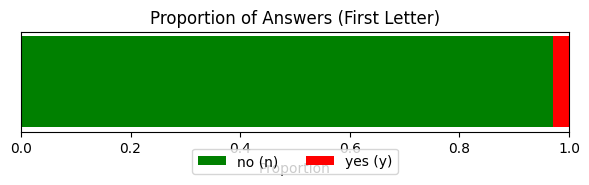

In [57]:
# Compute total counts by answer_first_letter for all questions combined
counts = df['answer_first_letter'].value_counts()
proportions = counts / counts.sum()

# Plot as a horizontal "width bar" that visually indicates the relative proportions using a horizontal stacked bar
fig, ax = plt.subplots(figsize=(6, 2))
segments = []
colors = []
labels = []
start = 0
for label, prop in proportions.items():
    if label == 'y':
        col = 'red'
        lab = 'yes (y)'
    elif label == 'n':
        col = 'green'
        lab = 'no (n)'
    else:
        col = 'gray'
        lab = 'other'
    ax.barh([0], [prop], left=[start], height=0.6, color=col, label=lab if lab not in labels else None)
    labels.append(lab)
    start += prop

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Proportion')
ax.set_title('Proportion of Answers (First Letter)')
# Handle possible duplicate labels in the legend
handles, legend_labels = ax.get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
ax.legend(unique.values(), unique.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.tight_layout()
plt.show()

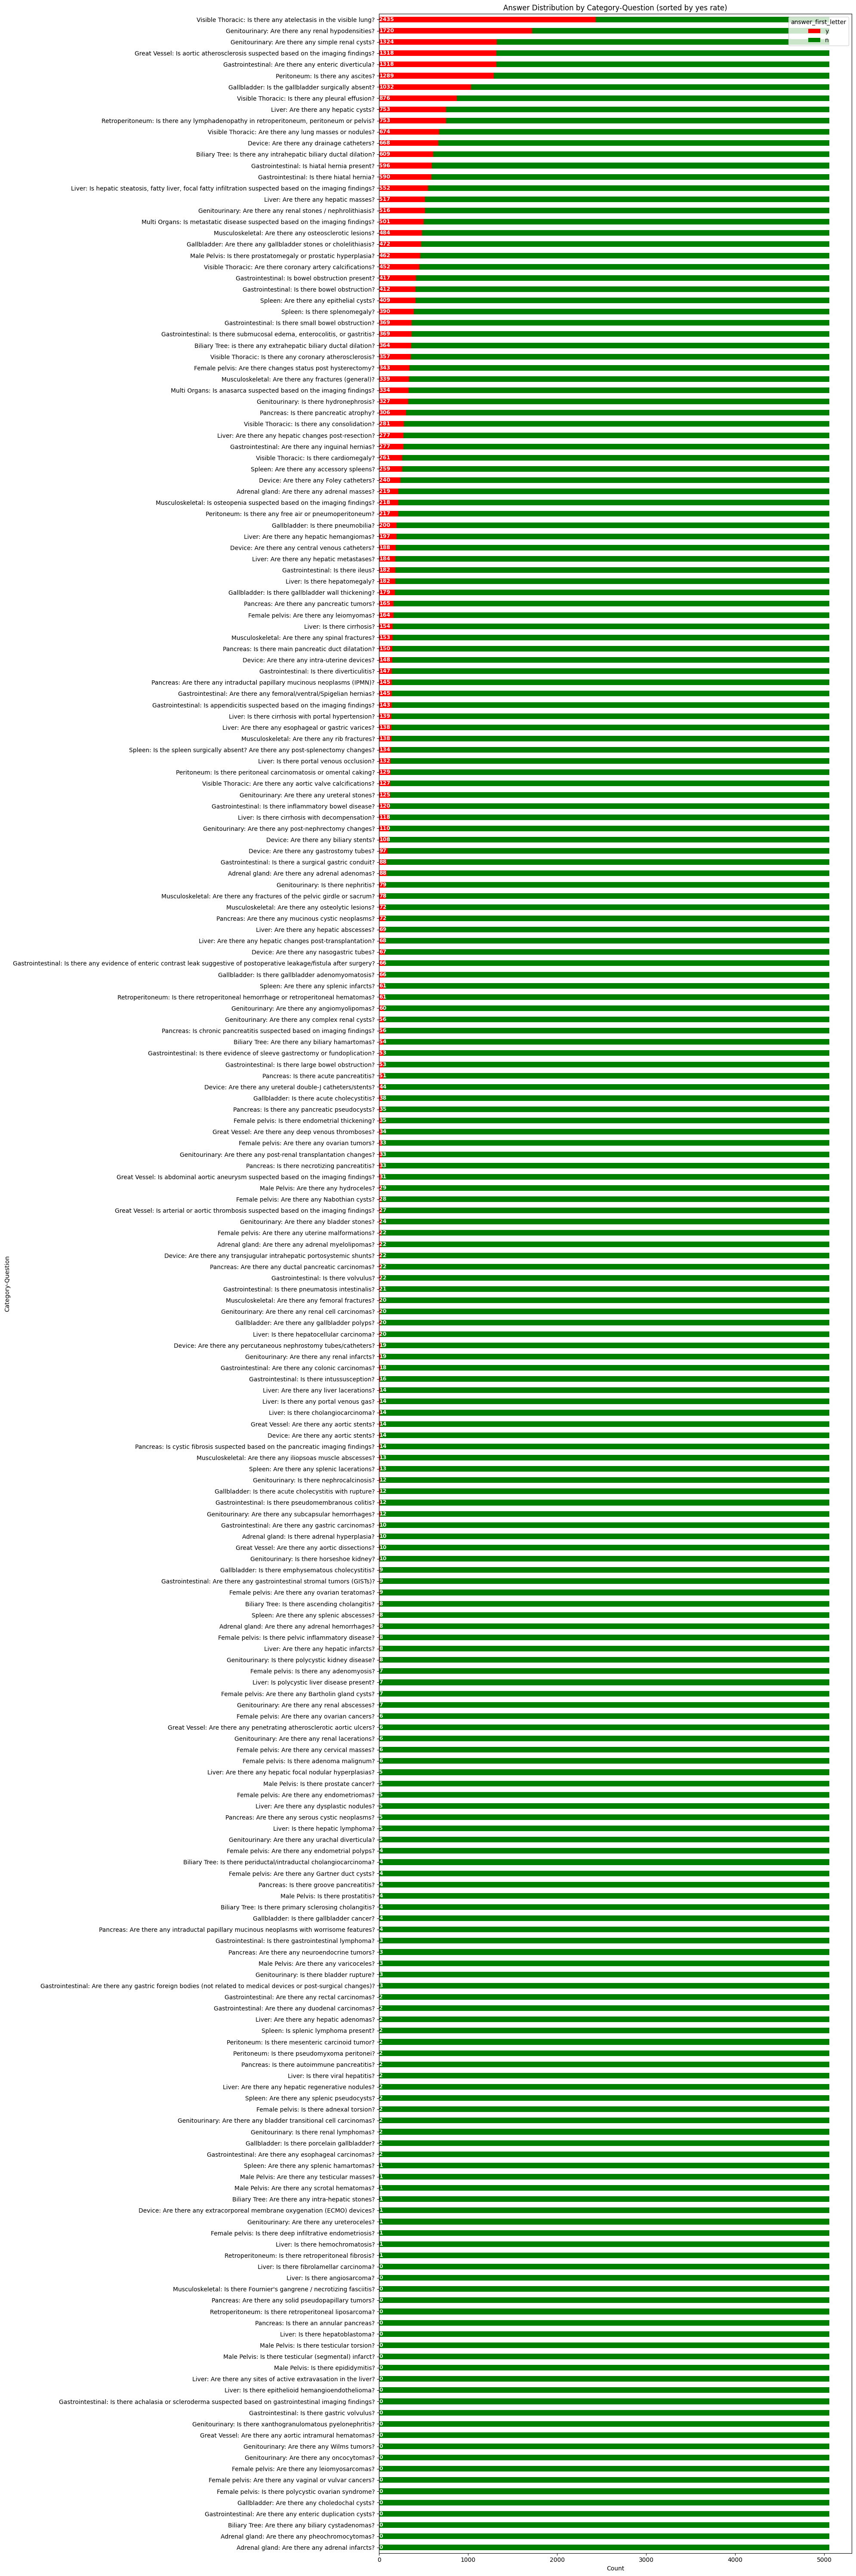

In [58]:
# now plot the same thing but for each category-question (transposed, horizontal bars), sorting by yes rate ('y' = red, 'n' = green)
import numpy as np

# Aggregate counts by category-question and answer first letter
bar_data = df.groupby(['category-question', 'answer_first_letter'])['answer_first_letter'].count().unstack(fill_value=0)

# Ensure both columns exist for all rows
for col in ['y', 'n']:
    if col not in bar_data.columns:
        bar_data[col] = 0

# Compute yes rate and sort
bar_data['yes_rate'] = bar_data['y'] / (bar_data['y'] + bar_data['n'] + (bar_data.drop(columns=['y','n','yes_rate'], errors='ignore').sum(axis=1) if bar_data.shape[1] > 3 else 0))
bar_data = bar_data.sort_values('yes_rate', ascending=True)

# Set bar colors: yes='y'=red, no='n'=green, others=gray
plot_cols = [col for col in ['y', 'n'] if col in bar_data.columns]
other_cols = [col for col in bar_data.columns if col not in ['y', 'n', 'yes_rate']]
bar_plot_colors = []
for col in plot_cols:
    if col == 'y':
        bar_plot_colors.append('red')      # Yes = red
    elif col == 'n':
        bar_plot_colors.append('green')    # No = green
for _ in other_cols:
    bar_plot_colors.append('gray')         # Others = gray

# Plot, drop yes_rate for plotting
ax = bar_data[plot_cols + other_cols].plot(
    kind='barh',
    stacked=True,
    figsize=(20, 60),
    color=bar_plot_colors
)
plt.xlabel("Count")
plt.ylabel("Category-Question")
plt.title("Answer Distribution by Category-Question (sorted by yes rate)")
plt.tight_layout()

# Write the number of yes on the bar
y_col_index = None
if 'y' in bar_data.columns:
    y_col_index = list(bar_data.columns).index('y')
    y_counts = bar_data['y'].values
    # For stacked bars, need "left" coordinates
    lefts = np.zeros(len(bar_data))
    # y IS the first col, so all lefts are zero
    lefts = np.zeros(len(bar_data))
    # Barh y positions are from 0 to len-1
    for i, (count, left) in enumerate(zip(y_counts, lefts)):
        if count >= 0:
            ax.text(left + 2, i, str(int(count)), va='center', ha='left', color='white', fontweight='bold', fontsize=9)

plt.show()


In [59]:
# sum up number of yes per report
df


,report_id,category,question_id,question,answer,category-question,answer_first_letter
0,1,Visible Thoracic,626e43b7,Is there any pleural effusion?,Yes,Visible Thoracic: Is there any pleural effusion?,y
1,1,Visible Thoracic,5e227a14,Are there coronary artery calcifications?,No,Visible Thoracic: Are there coronary artery ca...,n
2,1,Visible Thoracic,5671019d,Is there cardiomegaly?,No,Visible Thoracic: Is there cardiomegaly?,n
3,1,Visible Thoracic,fb482273,Is there any consolidation?,No,Visible Thoracic: Is there any consolidation?,n
4,1,Visible Thoracic,4c34a8d7,Is there any coronary atherosclerosis?,No,Visible Thoracic: Is there any coronary athero...,n
...,...,...,...,...,...,...,...
1142425,5054,Peritoneum,b6ed3a95,Is there any free air or pneumoperitoneum?,No,Peritoneum: Is there any free air or pneumoper...,n
1142426,5054,Peritoneum,b7881e53,Is there any ascites?,No,Peritoneum: Is there any ascites?,n
1142427,5054,Peritoneum,e5a6f934,Is there peritoneal carcinomatosis or omental ...,No,Peritoneum: Is there peritoneal carcinomatosis...,n
1142428,5054,Multi Organs,c638bfa1,Is anasarca suspected based on the imaging fin...,No,Multi Organs: Is anasarca suspected based on t...,n


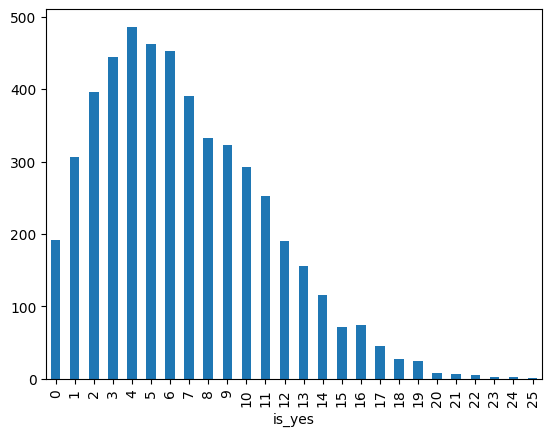

In [62]:
# Calculate yes counts per report (how many reports have 1 yes, 2 yes, etc.)
df['is_yes'] = df['answer_first_letter'] == 'y'
yes_per_report = df.groupby('report_id')['is_yes'].sum()
yes_distribution = yes_per_report.value_counts().sort_index()
yes_distribution.plot(kind='bar')
plt.show()
